In [42]:
! rm -rf /content/*

In [ ]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 1


Processed 10000 / 60000 images...
Processed 20000 / 60000 images...
Processed 30000 / 60000 images...
Processed 40000 / 60000 images...
Processed 50000 / 60000 images...
Processed 60000 / 60000 images...
✅ Augmented MNIST saved as 'augmented_mnist.npz'
Epoch 1/100

Epoch 1: val_loss improved from inf to 0.28502, saving model to best_mnist_model.keras
1688/1688 - 18s - 11ms/step - accuracy: 0.8147 - loss: 0.5937 - val_accuracy: 0.9130 - val_loss: 0.2850 - learning_rate: 1.0000e-03
Epoch 2/100

Epoch 2: val_loss improved from 0.28502 to 0.22588, saving model to best_mnist_model.keras
1688/1688 - 11s - 6ms/step - accuracy: 0.8939 - loss: 0.3461 - val_accuracy: 0.9315 - val_loss: 0.2259 - learning_rate: 1.0000e-03
Epoch 3/100

Epoch 3: val_loss improved from 0.22588 to 0.20527, saving model to best_mnist_model.keras
1688/1688 - 4s - 3ms/step - accuracy: 0.9093 - loss: 0.2944 - val_accuracy: 0.9362 - val_loss: 0.2053 - learning_rate: 1.0000e-03
Epoch 4/100

Epoch 4: val_loss improved from 0

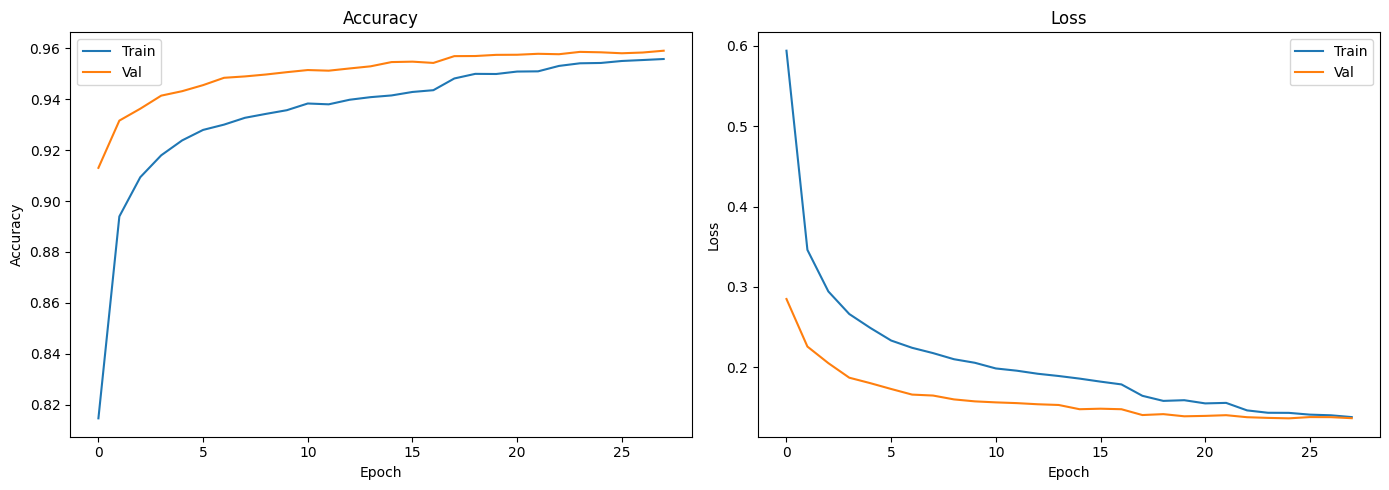

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


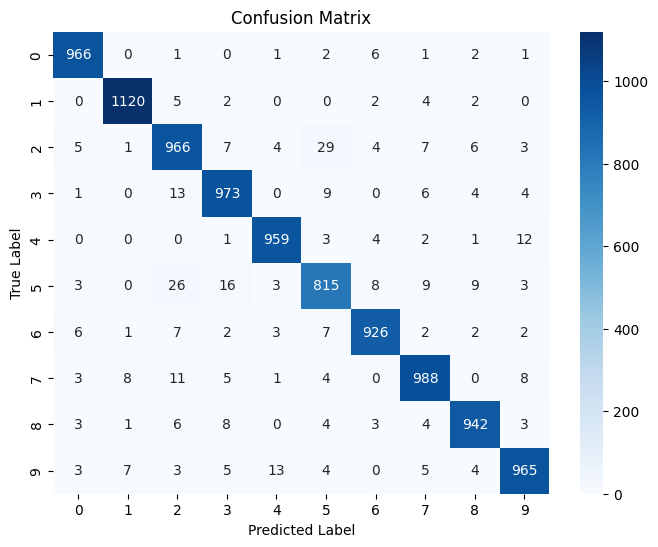


📋 Classification Report:
              precision    recall  f1-score   support

           0     0.9758    0.9857    0.9807       980
           1     0.9842    0.9868    0.9855      1135
           2     0.9306    0.9360    0.9333      1032
           3     0.9549    0.9634    0.9591      1010
           4     0.9746    0.9766    0.9756       982
           5     0.9293    0.9137    0.9214       892
           6     0.9717    0.9666    0.9691       958
           7     0.9611    0.9611    0.9611      1028
           8     0.9691    0.9671    0.9681       974
           9     0.9640    0.9564    0.9602      1009

    accuracy                         0.9620     10000
   macro avg     0.9615    0.9613    0.9614     10000
weighted avg     0.9620    0.9620    0.9620     10000



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import cv2
from sklearn.utils import shuffle



def augment_image(img):
    """Return horizontal flip, vertical flip, and 90° rotation of the input image"""
    return [
        cv2.flip(img, 1),  # horizontal flip
        cv2.flip(img, 0),  # vertical flip
        cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)  # rotate 90°
    ]

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# Augment training set
X_aug, y_aug = [], []
for i in range(len(x_train)):
    img = x_train[i]
    label = y_train[i]

    X_aug.append(img)        # Original
    y_aug.append(label)

    for aug in augment_image((img * 255).astype(np.uint8)):  # Convert to uint8 for OpenCV
        aug = aug.astype("float32") / 255.0                  # Normalize again
        X_aug.append(aug)
        y_aug.append(label)

    if (i + 1) % 10000 == 0:
        print(f"Processed {i+1} / {len(x_train)} images...")

# Convert to NumPy arrays
X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

# Shuffle the augmented data
X_aug, y_aug = shuffle(X_aug, y_aug, random_state=42)

# One-hot encode labels for training
# y_train_cat = to_categorical(y_train, 10)
# One-hot encode labels for augmented data
y_aug_cat = to_categorical(y_aug, 10)
y_test_cat = to_categorical(y_test, 10)

# Save to .npz (compressed format)
np.savez_compressed("augmented_mnist.npz", X=X_aug, y=y_aug)
print("✅ Augmented MNIST saved as 'augmented_mnist.npz'")


# Build the model
model = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')  # 10-class output
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',     # Watch validation loss
    patience=3,             # Wait for 3 epochs without improvement
    restore_best_weights=True,  # Restore weights from best epoch
    verbose=1
)

# Model checkpoint: save best model based on val_loss
checkpoint = ModelCheckpoint(
    filepath='best_mnist_model.keras',  # .keras format
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Reduce LR when a plateau is detected
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


# Train the model and save training history
history = model.fit(
    # x_train, y_train_cat,
    X_aug, y_aug_cat,
    epochs=100,                  # Set higher limit; early stop will terminate early
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint, reduce_lr],  # 👈 Add all three
    verbose=2
)


# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc:.4f}, Loss: {test_loss:.4f}")

# 🔐 Save the model for Gradio App
# model.save("mnist_gradio_model.keras")
# print("Model saved ............")

# Plot training and validation accuracy/loss
def plot_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axs[0].plot(history.history['accuracy'], label='Train')
    axs[0].plot(history.history['val_accuracy'], label='Val')
    axs[0].set_title('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()

    # Loss
    axs[1].plot(history.history['loss'], label='Train')
    axs[1].plot(history.history['val_loss'], label='Val')
    axs[1].set_title('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

# Confusion matrix
y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, digits=4))


In [ ]:
"""
(None, 28, 28): That means your model expects input shaped like:
1. A batch of images (hence the None),
2. Each image is a 2D array of shape (28, 28) (no channel dimension).
"""
model.input_shape

(None, 28, 28)

In [ ]:
import gradio as gr
from tensorflow.keras.models import load_model
from PIL import Image, ImageEnhance, ImageOps
import pandas as pd
import numpy as np
from skimage.io import imread
from skimage.transform import resize
import io


model = load_model("best_mnist_model.keras")

def convert_numpy_image_to_pillow(image):
  """
  To save the preprocessed MNIST-style image (the one passed to the model) for visualization, you can:
  1. Convert the mnist_like_image (which is a NumPy array) to a PIL image.
  2. Scale it from [0, 1] to [0, 255].
  3. Convert it to uint8 and save.
  """
  # ✅ Save the processed image for visualization
  image_to_save = (image * 255).astype(np.uint8)
  image_pil = Image.fromarray(image_to_save)
  image_pil.save("mnist_like_input.png")  # You can change the filename/path


def enhance_images(image):
  # Create an enhancer object for contrast
  factor = 32.5
  enhancer = ImageEnhance.Contrast(image)
  enhanced_image = enhancer.enhance(factor)  # Enhance the contrast

  return enhanced_image


def pad_image_to_square(image):
    """
    Pad the image equally on the shorter side to make it square.
    """
    height, width = image.shape[:2]
    if height == width:
        return image

    diff = abs(height - width)
    pad_before = diff // 2
    pad_after = diff - pad_before

    if height < width:
        padding = ((pad_before, pad_after), (0, 0), (0, 0))
    else:
        padding = ((0, 0), (pad_before, pad_after), (0, 0))

    return np.pad(image, padding, mode='constant', constant_values=0)


def threshold_image(grayscale_image, threshold=0.5):
    """
    Convert grayscale image to binary (0 or 1) using a threshold.
    """
    return (grayscale_image > threshold).astype(float)


def convert_to_mnist_style(image):
    # Pad to square
    image = pad_image_to_square(image)

    # Convert to grayscale using weighted average method
    grayscale_image = image.dot([0.07, 0.72, 0.21])

    # Invert grayscale so digit is white
    inverted = 1.0 - grayscale_image

    # Resize to 28x28
    final_image = resize(inverted, (28, 28), anti_aliasing=True)

    return final_image



# Define prediction function
def predict_digit(image: Image.Image):
    # Read the image using PIL and convert to numpy array
    pil_image = image.convert("RGB")

    pil_image = enhance_images(pil_image)

    image = np.array(pil_image) / 255.0  # Normalize

    mnist_like_image = convert_to_mnist_style(image)

    convert_numpy_image_to_pillow(mnist_like_image)

    # Step 3: Flatten the image
    reshaped = mnist_like_image.reshape(1, 28, 28)  # ✅ no channel dimension

    # Predict using the model
    prediction = model.predict(reshaped)[0]
    return {str(i): float(prediction[i]) for i in range(10)}

# Gradio interface
interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="MNIST Digit Classifier",
    description="Draw a digit (0-9) and get the model's prediction."
)

# Launch the app
interface.launch(debug=True, share=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://bfa19e9c230550a59a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://bfa19e9c230550a59a.gradio.live


In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image, ImageOps
import pandas as pd


# model = load_model("best_mnist_model.keras")

model = load_model("best_mnist_model.keras")

# Define prediction function
def predict_digit(image: Image.Image):
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image.astype(np.uint8))

    # Step 2: Convert uploaded image to grayscale and resize to 28x28
    if image.mode != "L":
        image = image.convert("L")
    image = image.resize((28, 28))  # Resize to MNIST size

    # Invert the image here
    image = ImageOps.invert(image)

    # Step 3: Flatten the image
    flattened = np.array(image).reshape(1, -1)  # shape = (1, 784)
    data = pd.DataFrame(flattened)

    # Step 4: Reshape, Normalize, Show, and Save
    for i in range(1):  # Only one image
        sample = np.reshape(
            data.iloc[i].values / 255.0, (28, 28)
        )  # Normalize like MNIST

        # Convert back to image format (0–255) for saving
        img_to_save = Image.fromarray((sample * 255).astype(np.uint8))
        img_to_save.save("mnist_like.png")  # Save as PNG

        print("Image saved as mnist_like.png")

    image_np = sample.reshape(
        1, 28, 28
    )  # Proper input shape: (n_samples, height, width)

    # Predict using the model
    prediction = model.predict(image_np)[0]
    return {str(i): float(prediction[i]) for i in range(10)}

# Gradio interface
interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="MNIST Digit Classifier",
    description="Draw a digit (0-9) and get the model's prediction."
)

# Launch the app
interface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b770410835655a17c6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image

# Load the trained model
model = load_model("best_mnist_model (1).keras")

# Define prediction function
def predict_digit(img: Image.Image):
    # Convert to grayscale and resize to 28x28
    img = img.convert("L").resize((28, 28))

    # Convert to numpy array and normalize
    img_array = np.array(img).astype("float32") / 255.0

    # Invert colors: MNIST digits are white on black
    img_array = 1.0 - img_array

    # Reshape to match model input
    img_array = img_array.reshape(1, 28, 28)

    # Predict
    prediction = model.predict(img_array)[0]
    return {str(i): float(prediction[i]) for i in range(10)}


# Gradio interface
interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="MNIST Digit Classifier",
    description="Draw a digit (0-9) and get the model's prediction."
)

# Launch the app
interface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://951906b7d4f629626d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
